## Exploration of relationship between early childhood provisions and deprivation indices, and early years development in England


#### Imports

In [16]:
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import zscore
from scipy.stats import spearmanr
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"
import geopandas as gpd

from config import DATABASE_PATH, PROJECT_ROOT

In the below analyses I focus on the impact of deprivation and various provision factors on early years development on the local authority district level. However, if you are interested in the impact of these factors on early developement more on the individual child scale, you can use weighted least squares (WLS) regression, which allows you to give more weight to local authority districts with more children. This can help to account for the fact that some districts have more children than others, and therefore may provide a more accurate picture of the overall relationship between deprivation and early development.

In [17]:
# Set some options for analysis
MODEL_TYPE = sm.OLS  # OLS or WLS
N_FOLDS = 10  # cross-validation folds
RANDOM_STATE = 42  # random seed; any int
EYFSP_YEAR = 202425  # year of
GDHI_YEAR = "2023"
OUTLIER_SD = 5  # clip z-scores beyond +/- this; np.inf to disable

Define fitting function for linear regression depending on `MODEL_TYPE`, and a cross-validation helper.

In [18]:
def fit(y: pd.Series, X: pd.Series | pd.DataFrame, weights: pd.Series | None = None):
    """Fit a linear regression model (OLS or WLS) with a constant term."""
    if MODEL_TYPE is sm.WLS:
        return sm.WLS(y, sm.add_constant(X), weights=weights).fit()
    elif MODEL_TYPE is sm.OLS:
        return sm.OLS(y, sm.add_constant(X)).fit()
    else:
        raise ValueError("Unsupported model type")


def cv_r2(X: pd.Series | pd.DataFrame, y: pd.Series, weights: pd.Series | None = None, n_splits: int = N_FOLDS) -> tuple[float, float, float]:
    """K-fold cross-validated R2. Returns mean, std, p (Wilcoxon two-sided test vs 0)."""
    from scipy.stats import wilcoxon
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        w = weights.iloc[train_idx] if weights is not None else None
        m = fit(y_tr, X_tr, weights=w)
        y_pred = m.predict(sm.add_constant(X_te))
        ss_res = np.sum((y_te - y_pred) ** 2)
        ss_tot = np.sum((y_te - y_te.mean()) ** 2)
        scores.append(1 - ss_res / ss_tot)
    scores = np.array(scores)
    _, p = wilcoxon(scores, alternative="two-sided")
    return np.mean(scores), np.std(scores), p

### Part 0: Data extraction and preprocessing
In this analysis I will be using the EYFSP dataset (2024/25), which records the percentage of children achieving a Good Level of Development in each local authority district, and the Indices of Deprivation (2019), which measure area-level deprivation across seven domains. I first check for mismatches between the two datasets, since local government restructuring between 2019 and 2025 means some district codes no longer align.

In [19]:
# Check for mismatches between EYFSP and IMD data

# -- Left join EYFSP to IMD to find EYFSP records without a match in IMD
query = ("select eyfsp.lad_code, eyfsp.lad_name, imd.la_code, imd.la_name "
         "from eyfsp "
         "left join imd on eyfsp.lad_code = imd.la_code "
         "where imd.la_code is NULL")
with sqlite3.connect(DATABASE_PATH) as conn:
    eyfsp_join = pd.read_sql_query(query, conn)

# -- Left join IMD to EYFSP to find IMD records without a match in EYFSP
query = ("select eyfsp.lad_code, eyfsp.lad_name, imd.la_code, imd.la_name "
         "from imd "
         "left join eyfsp on imd.la_code = eyfsp.lad_code "
         "where eyfsp.lad_code is NULL")
with sqlite3.connect(DATABASE_PATH) as conn:
    imd_join = pd.read_sql_query(query, conn)

if eyfsp_join.empty and imd_join.empty:
    print("No mismatches between EYFSP and IMD data.")
else:
    print("Mismatches found between EYFSP and IMD data:")
    print(f"EYFSP districts without IMD matches:\n{eyfsp_join.lad_name.unique()}")
    print(f"IMD districts without EYFSP matches:\n{imd_join.la_name.unique()}")

Mismatches found between EYFSP and IMD data:
EYFSP districts without IMD matches:
<StringArray>
[                             nan,                     'Cumberland',
        'Westmorland and Furness',                       'Barnsley',
                'North Yorkshire',                      'Sheffield',
         'North Northamptonshire',          'West Northamptonshire',
                'Buckinghamshire',                       'Somerset',
 'Outside of England and unknown']
Length: 11, dtype: str
IMD districts without EYFSP matches:
<StringArray>
[        'Aylesbury Vale',               'Chiltern',            'South Bucks',
                'Wycombe',                  'Corby',               'Daventry',
  'East Northamptonshire',              'Kettering',            'Northampton',
 'South Northamptonshire',         'Wellingborough']
Length: 11, dtype: str


These mismatches are likely due to local government restructuring between 2019 (when the IMD was published) and 2021-2025 (the EYFSP data). Let's count how many districts are matched vs unmatched to understand the scale of the issue.

In [20]:
# Count matched vs unmatched districts
query = """
        select count(distinct eyfsp.lad_code) as total_eyfsp_districts
        from eyfsp
        where geographic_level = 'Local authority district'
          and lad_code != 'z'
          and lad_code is not null \
        """
with sqlite3.connect(DATABASE_PATH) as conn:
    total = pd.read_sql_query(query, conn).iloc[0, 0]

query = """
        select count(distinct eyfsp.lad_code) as matched_districts
        from eyfsp
                 inner join imd on eyfsp.lad_code = imd.la_code
        where eyfsp.geographic_level = 'Local authority district' \
        """
with sqlite3.connect(DATABASE_PATH) as conn:
    matched = pd.read_sql_query(query, conn).iloc[0, 0]

print(f"Matched {matched} of {total} EYFSP districts ({matched / total:.0%}) to IMD records.")
print(f"Dropped {total - matched} districts due to restructuring or code changes.")

Matched 306 of 315 EYFSP districts (97%) to IMD records.
Dropped 9 districts due to restructuring or code changes.


A 3% loss is minimal - I can proceed with the matched districts without remapping. The unmatched districts are dropped via an inner join.

In [21]:
with open(Path(PROJECT_ROOT / "sql" / "EYFSP_and_IMD.sql")) as f:
    query = f.read()

with sqlite3.connect(DATABASE_PATH) as conn:
    df = pd.read_sql_query(query, conn, params=[202425])  # Load data for 2024/25

df.head(5)

,lad_code,lad_name,children_count,gld_children_count,gld_children_percent,imd_score
0,E06000047,County Durham,4861,3163,65.068915,26.793
1,E06000005,Darlington,1132,735,64.929328,25.657
2,E08000037,Gateshead,1912,1271,66.474895,28.217
3,E06000001,Hartlepool,1024,666,65.039062,35.037
4,E06000002,Middlesbrough,1794,1106,61.649944,40.460


Check for missing data and correct data types to ensure the data is clean and ready for analysis.

In [22]:
# Check for missing IMD scores

if df["imd_score"].isna().any():
    # Check how many records have missing IMD scores
    missing_count = df["imd_score"].isna().sum()
    total_count = len(df)
    print(f"Warning: {missing_count} out of {total_count} records have missing")
elif df["gld_children_percent"].isna().any():
    missing_count = df["gld_children_percent"].isna().sum()
    total_count = len(df)
    print(f"Warning: {missing_count} out of {total_count} records have missing GLD percentages.")
else:
    print("No missing data found.")


No missing data found.


In [23]:
# Check data types and adjust where necessary
print(f"Data type of imd_score: {df['imd_score'].dtype}")
print(f"Data type of gld_children_percent: {df['gld_children_percent'].dtype}")

Data type of imd_score: float64
Data type of gld_children_percent: float64


### Part 1: Do the individual indices of deprivation correlate with early years development?

The IMD is a composite of seven Indices of Deprivation (IoD). Rather than using the overall IMD score, I decompose deprivation into its constituent indices: Employment, Education, Health, Crime, Barriers to Housing and Services, Living Environment, and IDACI (Income Deprivation Affecting Children). I first check whether each index individually predicts GLD, then investigate how to interpret their contributions jointly.

In [24]:
with open(PROJECT_ROOT / "sql" / "EYFSP_and_IOD.sql") as f:
    query = f.read()

with sqlite3.connect(DATABASE_PATH) as conn:
    df_iod = pd.read_sql_query(query, conn, params=[EYFSP_YEAR])

df_iod = df_iod[df_iod["lad_name"] != "Isles of Scilly"]

iod_names = [
    "employment_score", "education_score", "health_score",
    "crime_score", "barriers_score", "living_score", "idaci_score",
]

cols_to_z = iod_names + ["gld_children_percent", "wealth_pounds"]
df_iod[cols_to_z] = df_iod[cols_to_z].apply(zscore)

for col in cols_to_z:
    df_iod[col] = df_iod[col].clip(-OUTLIER_SD, OUTLIER_SD)

print(f"{len(df_iod)} districts loaded")
df_iod.head()

286 districts loaded


,lad_code,lad_name,children_count,gld_children_count,gld_children_percent,wealth_pounds,employment_score,education_score,health_score,crime_score,barriers_score,living_score,idaci_score
0,E06000047,County Durham,4861,3163,-0.986440,-0.647765,1.439194,0.478976,1.316098,0.726136,-1.205590,-1.684820,1.104394
1,E06000005,Darlington,1132,735,-1.024203,-0.534348,1.006952,0.752923,1.034230,1.319966,-1.543400,-1.326467,0.786244
2,E08000037,Gateshead,1912,1271,-0.606081,-0.677451,1.323930,0.693848,1.496621,0.919430,-0.648330,-1.043945,0.802988
3,E06000001,Hartlepool,1024,666,-0.994517,-0.639106,2.649472,1.076421,1.567880,1.335908,-1.182358,-1.539824,2.125826
4,E06000002,Middlesbrough,1794,1106,-1.911374,-0.796863,2.822368,2.050997,2.082528,1.604925,-1.191620,-0.852073,2.862596


Fit a simple regression for each IoD index individually against GLD to check whether each one correlates with school readiness.

In [25]:
y = df_iod["gld_children_percent"]
weights = df_iod["children_count"]

raw_results = {}
for col in iod_names:
    m = fit(y, df_iod[col], weights=weights)
    cv_mean, cv_std, cv_p = cv_r2(df_iod[col], y, weights=weights)
    raw_results[col] = {
        "r2": m.rsquared,
        "coef": m.params.iloc[-1],
        "cv_r2": cv_mean,
        "cv_std": cv_std,
        "cv_p": cv_p,
    }

raw_summary = pd.DataFrame(raw_results).T.sort_values("r2", ascending=False)
raw_summary.style.format({"r2": "{:.3f}", "coef": "{:+.3f}", "cv_r2": "{:.3f}", "cv_std": "{:.3f}", "cv_p": "{:.3f}"})

,r2,coef,cv_r2,cv_std,cv_p
health_score,0.552,-0.743,0.505,0.094,0.002
education_score,0.495,-0.703,0.445,0.137,0.002
employment_score,0.481,-0.694,0.433,0.106,0.002
idaci_score,0.436,-0.660,0.384,0.138,0.002
crime_score,0.191,-0.437,0.130,0.113,0.004
barriers_score,0.098,+0.313,0.035,0.086,0.160
living_score,0.065,-0.255,-0.015,0.084,1.000


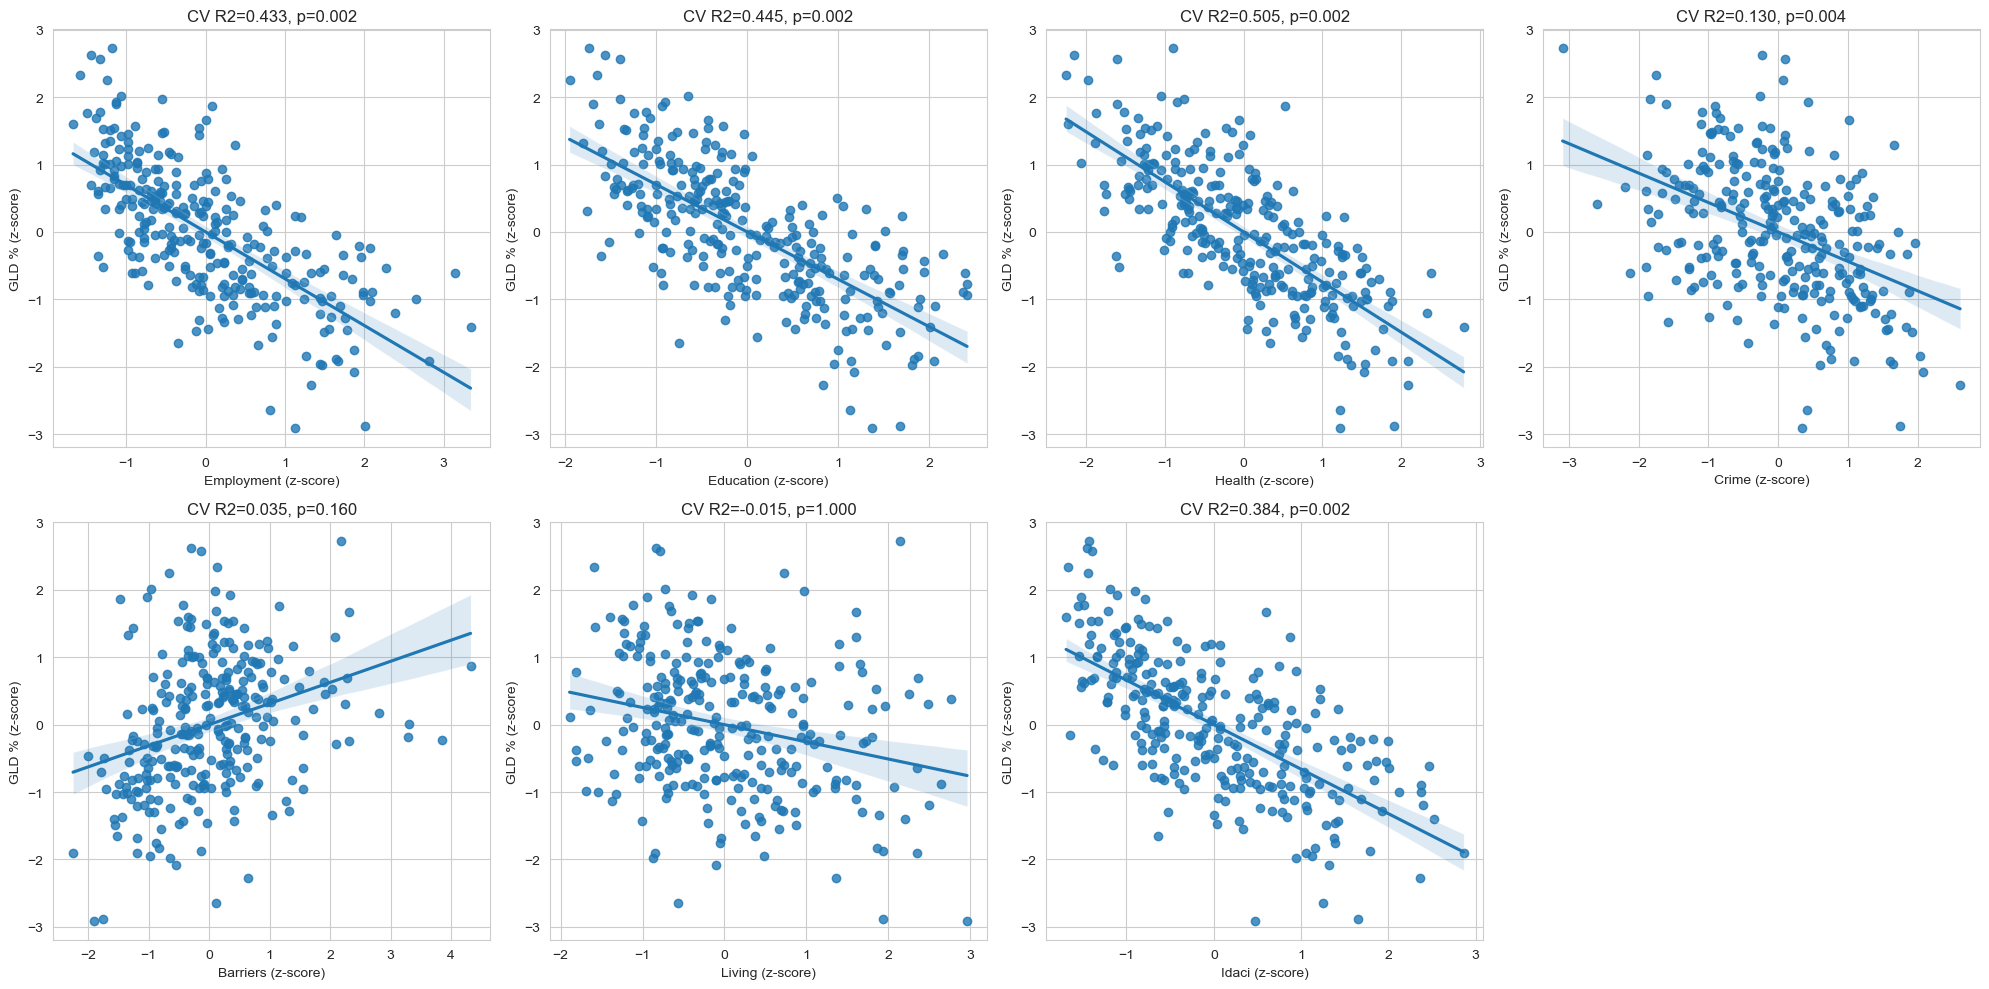

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.flatten(), iod_names):
    sns.regplot(x=df_iod[col], y=y, ax=ax)
    r2 = raw_results[col]["cv_r2"]
    p = raw_results[col]["cv_p"]
    label = col.replace("_score", "").replace("_", " ").title()
    ax.set_xlabel(f"{label} (z-score)")
    ax.set_ylabel("GLD % (z-score)")
    ax.set_title(f"CV R2={r2:.3f}, p={p:.3f}")
axes[-1, -1].set_visible(False)
plt.tight_layout()

As expected, most IoD indices correlate strongly with early years development. Health, Education, Employment, and IDACI are the strongest individual predictors (R2 ~ 0.40-0.50). Crime and Living Environment are weaker but significant. Barriers is the only index with a positive coefficient - areas with worse access to services tend to have *better* GLD outcomes - perhaps because high-barriers areas are predominantly affluent rural districts where distance to local services is greater, or because large cities with housing deprivation also tend to have stronger educational infrastructure and outcomes.

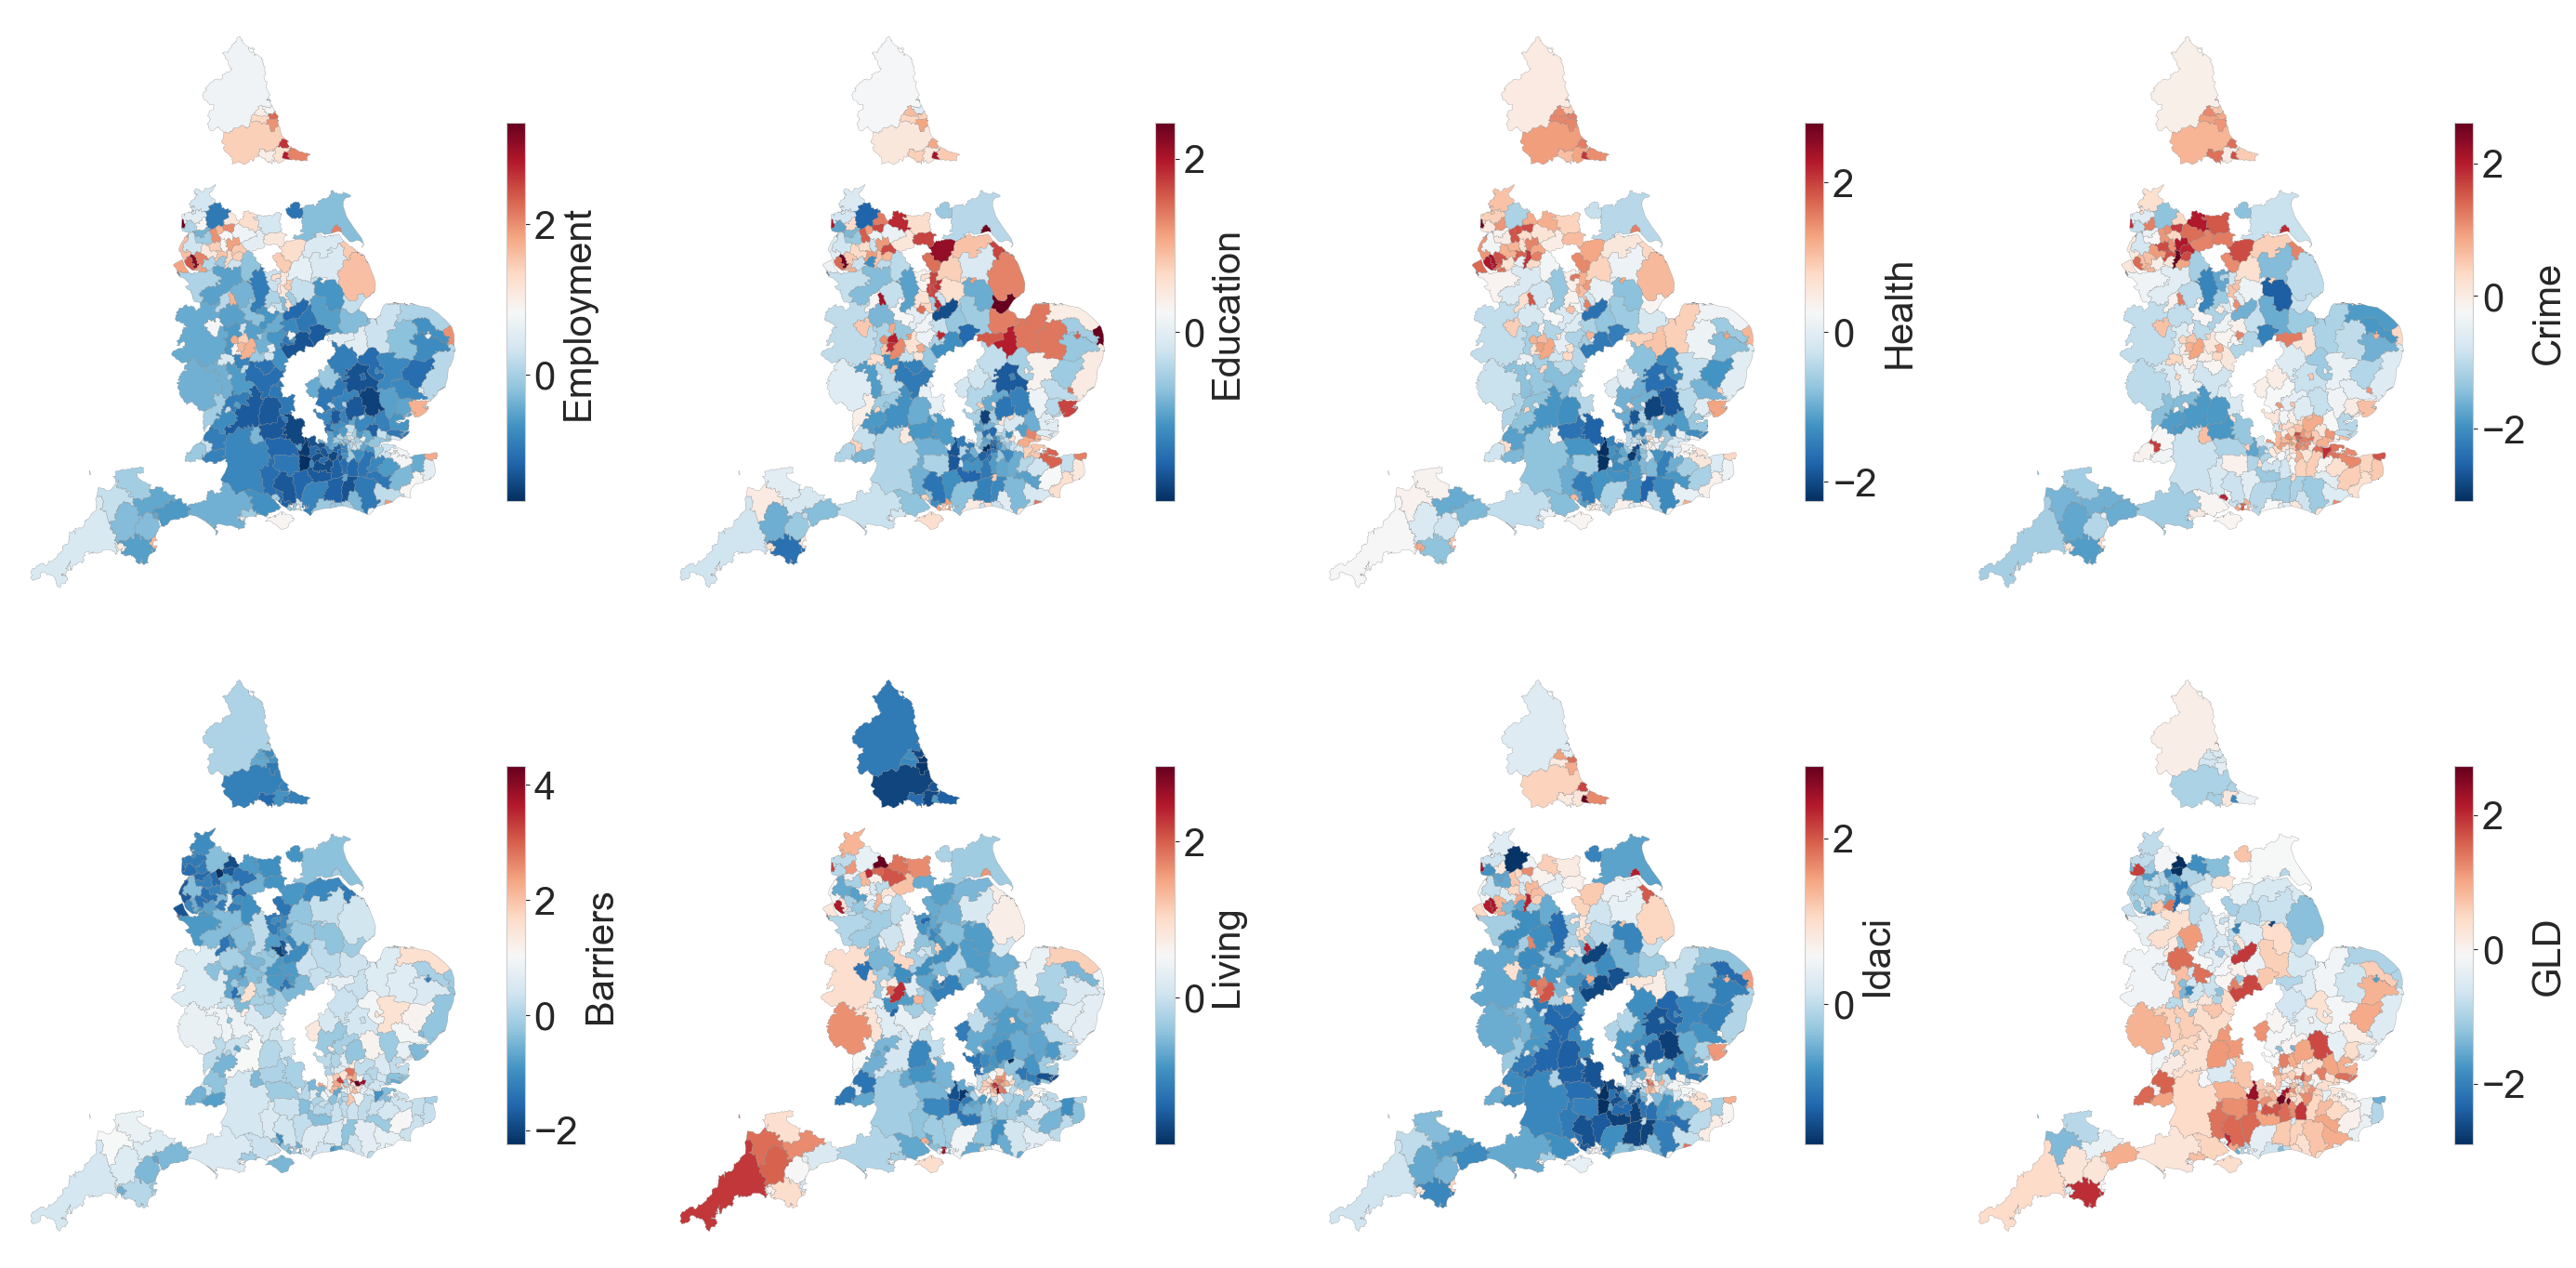

In [27]:
# Load LAD boundaries (2024, ultra-generalised)
gdf = gpd.read_file(PROJECT_ROOT / "data" / "lad_boundaries.geojson")
gdf = gdf[gdf["LAD24CD"].str.startswith("E")]  # England only

# Merge with IoD scores and GLD
gdf = gdf.merge(df_iod[["lad_code", "lad_name", "gld_children_percent"] + iod_names],
                left_on="LAD24CD", right_on="lad_code", how="inner")

cols = iod_names + ["gld_children_percent"]
titles = [c.replace("_score", "").replace("_", " ").title() for c in iod_names] + ["GLD"]

fig, axes = plt.subplots(2, 4, figsize=(28, 14))
for ax, col, title in zip(axes.flatten(), cols, titles):
    gdf.plot(column=col, cmap="RdBu_r", legend=True, ax=ax,
             edgecolor="grey", linewidth=0.2,
             legend_kwds={"shrink": 0.6, "label": title})
    ax.set_axis_off()

    cb = ax.get_figure().axes[-1]  # colorbar is the last axis added
    cb.tick_params(labelsize=30)
    cb.set_ylabel(title, fontsize=30)

plt.tight_layout()

fig.savefig(PROJECT_ROOT / "docs" / "map_iod.png")

The maps show that most deprivation indices share a similar spatial pattern, with higher scores in the North and Midlands. Barriers and Living Environment stand out - both are heavily concentrated in London, and Barriers is the only index where the colour pattern is flipped relative to GLD, consistent with its positive regression coefficient. This likely reflects a London effect - as the capital, it combines extreme housing pressures with relatively strong school outcomes.

These raw correlations however, may be confounded by general wealth: richer areas score lower on most deprivation indices *and* tend to have better educational outcomes. To isolate the relationship between each deprivation index and GLD that isn't simply driven by wealth, I regress out household income (GDHI per head) from both the predictor and outcome.

### Part 1a: Controlling for wealth

Household income (GDHI per head) is likely to correlate with both deprivation and GLD, so any relationship we see between IoD indices and school readiness could partly be driven by wealth. Before controlling for it, let's check how strongly wealth correlates with everything.

Education                      r=-0.868, p=0.000
Health                         r=-0.827, p=0.000
Employment                     r=-0.763, p=0.000
Idaci                          r=-0.676, p=0.000
Crime                          r=-0.392, p=0.000
Living                         r=-0.079, p=0.184
Barriers                       r=+0.514, p=0.000
Gld Children Percent           r=+0.741, p=0.000


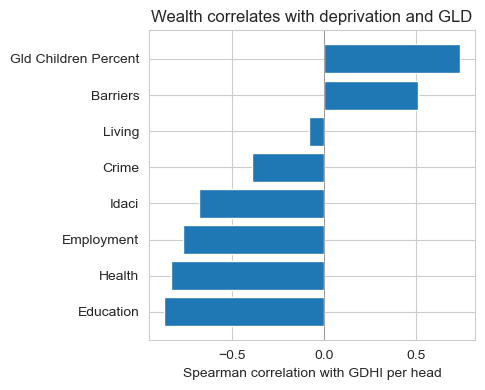

In [28]:
wealth_corrs = {}
for col in iod_names + ["gld_children_percent"]:
    r, p = spearmanr(df_iod["wealth_pounds"], df_iod[col])
    wealth_corrs[col] = r

wealth_corrs = pd.Series(wealth_corrs).sort_values()

fig, ax = plt.subplots(figsize=(5, 4))
labels = [c.replace("_score", "").replace("_", " ").replace("gld_children_percent", "GLD").title() for c in
          wealth_corrs.index]
ax.barh(labels, wealth_corrs)
ax.set_xlabel("Spearman correlation with GDHI per head")
ax.set_title("Wealth correlates with deprivation and GLD")
ax.axvline(0, color="grey", linewidth=0.5)
plt.tight_layout()

for col in wealth_corrs.index:
    r, p = spearmanr(df_iod["wealth_pounds"], df_iod[col])
    label = col.replace("_score", "").replace("_", " ").replace("gld_children_percent", "GLD").title()
    print(f"{label:30s} r={r:+.3f}, p={p:.3f}")

Wealth is significantly correlated with GLD and all IoD indices except Living Environment. To isolate the relationship between each deprivation index and GLD that isn't simply driven by income, I regress GDHI out of both the predictor and outcome before re-fitting.

In [29]:
wealth = df_iod["wealth_pounds"]

gld_sub_wealth = fit(y, wealth, weights=weights).resid # find residuals of relationship between GLD and household income, i.e. everything in GLD not explained by income

iod_sub_wealth = pd.DataFrame()
for col in iod_names:
    iod_sub_wealth[col] = fit(df_iod[col], wealth, weights=weights).resid # find residuals of relationship between each IOD and household income, i.e. everything in each IOD not explained by income

Full model: all wealth-controlled IoD indices predicting wealth-controlled GLD.

In [30]:
model_full = fit(gld_sub_wealth, iod_sub_wealth, weights=weights)
cv_mean, cv_std, cv_p = cv_r2(iod_sub_wealth, gld_sub_wealth, weights=weights)

print(f"R2 = {model_full.rsquared:.3f}, adj R2 = {model_full.rsquared_adj:.3f}")
print(f"CV R2 = {cv_mean:.3f} +/- {cv_std:.3f}, p = {cv_p:.3f}")

R2 = 0.438, adj R2 = 0.424
CV R2 = 0.327 +/- 0.218, p = 0.006


Compute single importance (one wealth-controlled index at a time) and unique importance (drop in adj. R2 when removing one index from the full model).

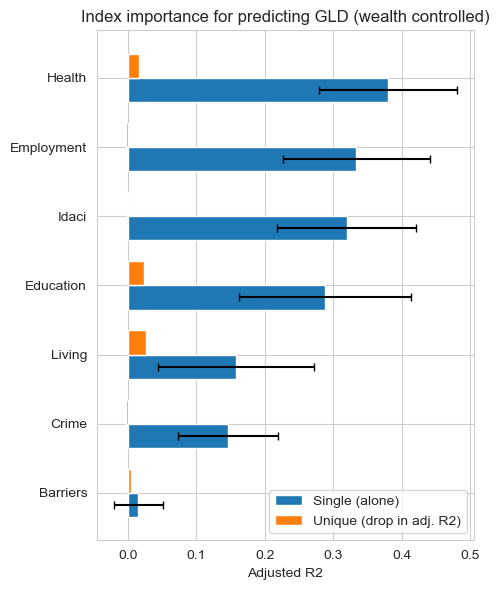

In [31]:
single_importance = {}
single_sem = {}
for col in iod_names:
    m = fit(gld_sub_wealth, iod_sub_wealth[col], weights=weights)
    single_importance[col] = m.rsquared_adj
    _, cv_std, _ = cv_r2(iod_sub_wealth[col], gld_sub_wealth, weights=weights)
    single_sem[col] = cv_std / np.sqrt(N_FOLDS)

unique_importance = {}
full_adj_r2 = model_full.rsquared_adj
for col in iod_names:
    remaining = [c for c in iod_names if c != col]
    m = fit(gld_sub_wealth, iod_sub_wealth[remaining], weights=weights)
    unique_importance[col] = full_adj_r2 - m.rsquared_adj

importance = pd.DataFrame({
    "Single": single_importance,
    "Single_sem": single_sem,
    "Unique": unique_importance,
})
importance = importance.sort_values("Single", ascending=True)

fig, ax = plt.subplots(figsize=(5, 6))
x = np.arange(len(importance))
width = 0.35
ax.barh(x - width / 2, importance["Single"], width,
        xerr=importance["Single_sem"] * 1.96, label="Single (alone)", capsize=3)
ax.barh(x + width / 2, importance["Unique"], width, label="Unique (drop in adj. R2)")
ax.set_yticks(x)
ax.set_yticklabels([c.replace("_score", "").replace("_", " ").title() for c in importance.index])
ax.set_xlabel("Adjusted R2")
ax.set_title("Index importance for predicting GLD (wealth controlled)")
ax.legend()
plt.tight_layout()

Several IoD indices have high single importance (i.e., can predict GLD on their own) but low unique importance. This suggests they share a lot of variance with each other - when combined in one model, each one's "unique" contribution shrinks because the others already account for similar information. Let's check this directly with a correlation heatmap.

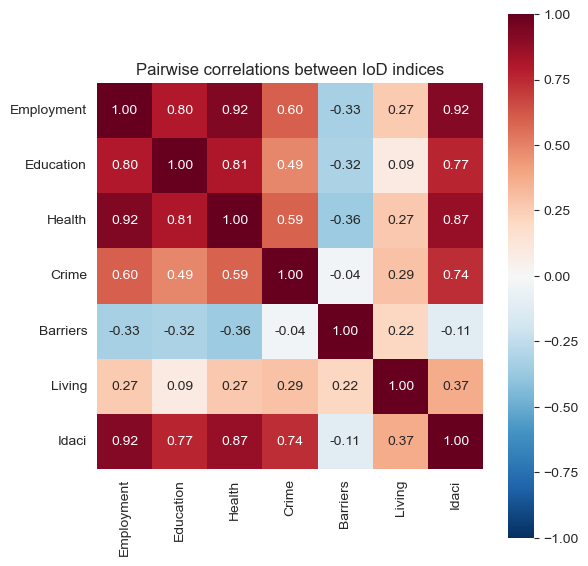

In [32]:
corr = df_iod[iod_names].corr()
labels = [c.replace("_score", "").replace("_", " ").title() for c in iod_names]

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            xticklabels=labels, yticklabels=labels)
ax.set_title("Pairwise correlations between IoD indices")
plt.tight_layout()

The IoD indices are substantially correlated - Employment, Health, Education, and IDACI all share r > 0.7 with each
other.

This multicollinearity means that in a full model, each index's coefficient reflects only its *unique* contribution after the others are accounted for, and the standard errors are inflated. Interpreting individual coefficients from the full model is therefore unreliable.

A more interpretable approach: fit a separate model for each IoD index (after controlling for wealth in both the predictor and outcome). This tells us how much each index *on its own* explains GLD variance beyond wealth, free from multicollinearity.

### Part 1b: Separate models per IoD index (wealth-controlled)

For each IoD index, I regress wealth out of both the IOD score and GLD, then fit a simple regression. This gives each index's relationship with school readiness after removing the influence of household income.

In [33]:
controlled_results = {}
for col in iod_names:
    m = fit(gld_sub_wealth, iod_sub_wealth[col], weights=weights)
    cv_mean, cv_std, cv_p = cv_r2(iod_sub_wealth[col], gld_sub_wealth, weights=weights)
    controlled_results[col] = {
        "r2": m.rsquared,
        "coef": m.params.iloc[-1],
        "cv_r2": cv_mean,
        "cv_std": cv_std,
        "cv_p": cv_p,
    }

controlled_summary = pd.DataFrame(controlled_results).T.sort_values("r2", ascending=False)
controlled_summary.style.format({
    "r2": "{:.3f}", "coef": "{:+.3f}",
    "cv_r2": "{:.3f}", "cv_std": "{:.3f}", "cv_p": "{:.3f}",
})

,r2,coef,cv_r2,cv_std,cv_p
health_score,0.382,-0.645,0.302,0.162,0.004
employment_score,0.336,-0.558,0.253,0.173,0.010
idaci_score,0.322,-0.521,0.250,0.164,0.006
education_score,0.291,-0.608,0.203,0.203,0.020
living_score,0.161,-0.338,0.078,0.183,0.105
crime_score,0.149,-0.330,0.081,0.118,0.084
barriers_score,0.019,+0.124,-0.044,0.057,0.084


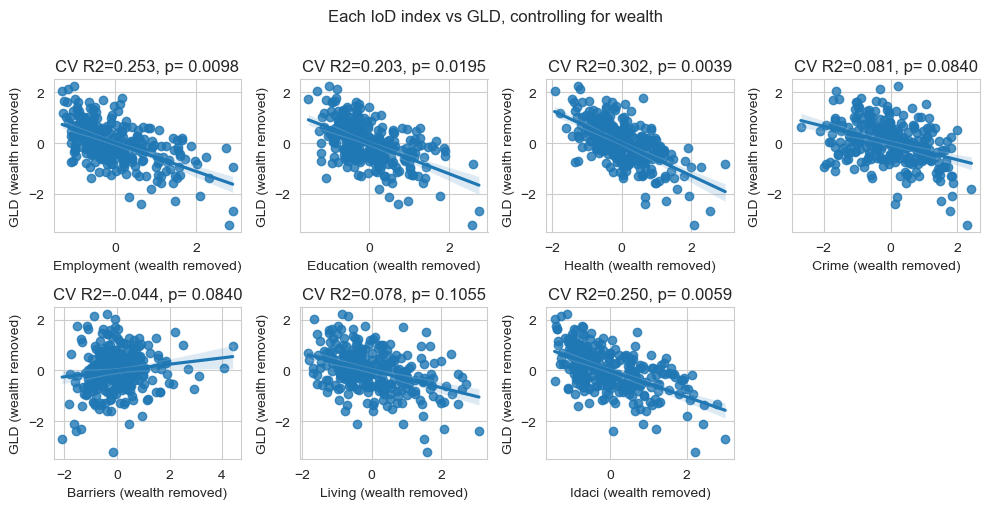

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, col in zip(axes.flatten(), iod_names):
    r2 = controlled_results[col]["cv_r2"]
    p = controlled_results[col]["cv_p"]
    label = col.replace("_score", "").replace("_", " ").title()
    sns.regplot(x=iod_sub_wealth[col], y=gld_sub_wealth, ax=ax)
    ax.set_xlabel(f"{label} (wealth removed)")
    ax.set_ylabel("GLD (wealth removed)")
    ax.set_title(f"CV R2={r2:.3f}, p={p: .4f}")
axes[-1, -1].set_visible(False)
fig.suptitle("Each IoD index vs GLD, controlling for wealth", y=1.01)
plt.tight_layout()

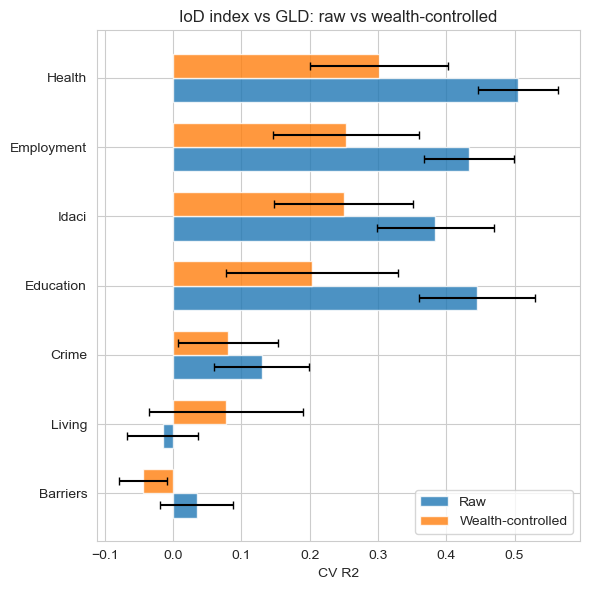

In [35]:
comparison = pd.DataFrame({
    "raw_r2": {col: raw_results[col]["cv_r2"] for col in iod_names},
    "raw_sem": {col: raw_results[col]["cv_std"] / np.sqrt(N_FOLDS) for col in iod_names},
    "controlled_r2": {col: controlled_results[col]["cv_r2"] for col in iod_names},
    "controlled_sem": {col: controlled_results[col]["cv_std"] / np.sqrt(N_FOLDS) for col in iod_names},
})
comparison = comparison.sort_values("controlled_r2", ascending=True)

fig, ax = plt.subplots(figsize=(6, 6))
x = np.arange(len(comparison))
width = 0.35
ax.barh(x - width / 2, comparison["raw_r2"], width,
        xerr=comparison["raw_sem"] * 1.96, label="Raw", alpha=0.8, capsize=3)
ax.barh(x + width / 2, comparison["controlled_r2"], width,
        xerr=comparison["controlled_sem"] * 1.96, label="Wealth-controlled", alpha=0.8, capsize=3)
ax.set_yticks(x)
ax.set_yticklabels([c.replace("_score", "").replace("_", " ").title() for c in comparison.index])
ax.set_xlabel("CV R2")
ax.set_title("IoD index vs GLD: raw vs wealth-controlled")
ax.legend()
plt.tight_layout()

fig.savefig(PROJECT_ROOT / "docs" / "raw_vs_wealth-controlled_IODs_GLD.png")


Even after controlling for wealth (GDHI) several IOD indices are still predictive of GLD outcomes (Health, Employment, Education, and IDACI.)

### Part 1c: PCA on significant IoD indices

Health, Employment, IDACI, and Education all significantly predict GLD after controlling for wealth, but they're highly correlated with each other. I run PCA on these four (wealth-controlled) IODs to extract a deprivation component to use as the control in Part 2.

Significant indices: ['employment_score', 'education_score', 'health_score', 'idaci_score']

CV variance explained: [0.85679829 0.07872758 0.04086334 0.02361079]

Loadings (full-data fit):
                       PC1       PC2       PC3       PC4
employment_score  0.541894 -0.222077 -0.146569  0.797214
education_score   0.393171  0.916239 -0.072657 -0.025377
health_score      0.485430 -0.273868 -0.643565 -0.524574
idaci_score       0.562250 -0.190222  0.747705 -0.297704


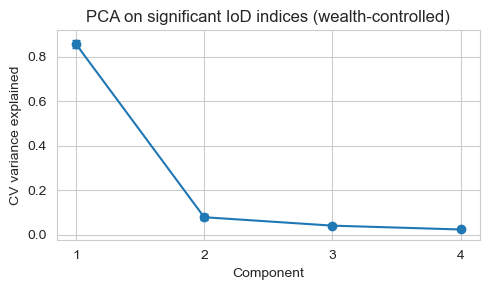

In [36]:
sig_iod_names = [col for col in iod_names if controlled_results[col]["cv_p"] < 0.05]
print(f"Significant indices: {sig_iod_names}")

sig_iod_sub_wealth = iod_sub_wealth[sig_iod_names]

pca = PCA()
pca.fit(sig_iod_sub_wealth)

n_pcs = len(sig_iod_names)
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_cumulative = np.zeros((N_FOLDS, n_pcs))

for fold, (train_idx, test_idx) in enumerate(kf.split(sig_iod_sub_wealth)):
    X_train = sig_iod_sub_wealth.iloc[train_idx].values
    X_test = sig_iod_sub_wealth.iloc[test_idx].values
    pca_fold = PCA().fit(X_train)
    X_test_centered = X_test - X_train.mean(axis=0)
    total_var = np.sum(X_test_centered ** 2)
    for k in range(n_pcs):
        scores = X_test_centered @ pca_fold.components_[:k + 1].T
        reconstruction = scores @ pca_fold.components_[:k + 1]
        cv_cumulative[fold, k] = 1 - np.sum((X_test_centered - reconstruction) ** 2) / total_var

cv_marginal = np.diff(cv_cumulative, prepend=0, axis=1)
cv_mean = cv_marginal.mean(axis=0)
cv_sem = cv_marginal.std(axis=0) / np.sqrt(N_FOLDS)

fig, ax = plt.subplots(figsize=(5, 3))
ax.errorbar(range(1, n_pcs + 1), cv_mean, yerr=cv_sem * 1.96, fmt="o-", capsize=3)
ax.set_xlabel("Component")
ax.set_ylabel("CV variance explained")
ax.set_title("PCA on significant IoD indices (wealth-controlled)")
ax.set_xticks(range(1, n_pcs + 1))
plt.tight_layout()

loadings = pd.DataFrame(
    pca.components_.T,
    index=sig_iod_names,
    columns=[f"PC{i + 1}" for i in range(n_pcs)]
)
print(f"\nCV variance explained: {cv_mean}")
print(f"\nLoadings (full-data fit):\n{loadings}")

In [37]:
pc_scores = pca.transform(sig_iod_sub_wealth)
pc_names = [f"PC{i + 1}" for i in range(len(sig_iod_names))]

for i, pc in enumerate(pc_names):
    df_iod[pc] = pc_scores[:, i]

pc_results = {}
for pc in pc_names:
    m = fit(gld_sub_wealth, df_iod[pc], weights=weights)
    cv_mean, cv_std, cv_p = cv_r2(df_iod[pc], gld_sub_wealth, weights=weights)
    pc_results[pc] = {
        "r2": m.rsquared,
        "coef": m.params.iloc[-1],
        "cv_r2": cv_mean,
        "cv_std": cv_std,
        "cv_p": cv_p,
    }

pc_summary = pd.DataFrame(pc_results).T
pc_summary.style.format({
    "r2": "{:.3f}", "coef": "{:+.3f}",
    "cv_r2": "{:.3f}", "cv_std": "{:.3f}", "cv_p": "{:.3f}",
})

,r2,coef,cv_r2,cv_std,cv_p
PC1,0.386,-0.336,0.307,0.181,0.004
PC2,0.002,-0.082,-0.052,0.054,0.004
PC3,0.012,+0.276,-0.051,0.070,0.049
PC4,0.008,+0.300,-0.052,0.072,0.084


Only the first component appears to meaningfully predict GLD (cv R2=0.307, cv p<0.01), so I retain 1 component. This suggests that all 4 IoD indices share a common underlying factor (general deprivation) that captures most of their variance.

### Part 2: Do early years provisions predict school readiness?

I first check whether provisions predict GLD raw (no controls), then with wealth regressed out.

The provision data is drawn from different reporting years to best match the children assessed in EYFSP 2024/25. The 2-year-old take-up figure is from 2022, since those children would have been 4-5 at the time of assessment. Universal take-up (2024), graduate staff (2024), and SEN (2024) reflect the cohort closest to the point of assessment, while Ofsted ratings (2025) were gathered for the most recent year.

In [38]:
with open(PROJECT_ROOT / "sql" / "provision_factors.sql") as f:
    query = f.read()

with sqlite3.connect(DATABASE_PATH) as conn:
    df_prov = pd.read_sql_query(query, conn, params=[EYFSP_YEAR])

df_prov = df_prov[df_prov["lad_name"] != "Isles of Scilly"]

provision_cols = [
    "eyp_takeup", "eyp_takeup_2yr", "ofsted_weighted_score",
    "sen_ehc_rate", "sen_early_identification_rate", "graduate_staff_percentage",
]

merged = df_iod.merge(df_prov[["lad_code"] + provision_cols], on="lad_code")
merged = merged.dropna(subset=provision_cols)

merged[provision_cols] = merged[provision_cols].apply(zscore)
for col in provision_cols:
    merged[col] = merged[col].clip(-OUTLIER_SD, OUTLIER_SD)

print(f"{len(merged)} districts with provision data")
merged[provision_cols].describe().round(2)

286 districts with provision data


,eyp_takeup,eyp_takeup_2yr,ofsted_weighted_score,sen_ehc_rate,sen_early_identification_rate,graduate_staff_percentage
count,286.00,286.00,286.00,286.00,286.00,286.00
mean,0.01,-0.00,0.01,0.00,0.00,-0.00
std,0.91,1.00,0.95,1.00,1.00,1.00
min,-5.00,-3.05,-5.00,-1.99,-2.65,-4.16
25%,-0.27,-0.73,-0.45,-0.72,-0.66,-0.37
50%,0.15,-0.01,-0.01,-0.16,0.26,0.14
75%,0.38,0.75,0.59,0.56,0.73,0.47
max,2.69,3.75,5.00,4.31,1.71,2.86


First, raw provision vs GLD (no controls except z-scoring and outlier clipping).

In [39]:
merged_weights = merged["children_count"]
merged_wealth = merged["wealth_pounds"]
merged_gld = merged["gld_children_percent"]

prov_nocontrol_results = {}
for col in provision_cols:
    m = fit(merged_gld, merged[col], weights=merged_weights)
    cv_mean, cv_std, cv_p = cv_r2(merged[col], merged_gld, weights=merged_weights)
    prov_nocontrol_results[col] = {
        "r2": m.rsquared,
        "coef": m.params.iloc[-1],
        "cv_r2": cv_mean,
        "cv_std": cv_std,
        "cv_p": cv_p,
    }

prov_nocontrol_summary = pd.DataFrame(prov_nocontrol_results).T.sort_values("r2", ascending=False)
prov_nocontrol_summary.style.format({
    "r2": "{:.3f}", "coef": "{:+.3f}",
    "cv_r2": "{:.3f}", "cv_std": "{:.3f}", "cv_p": "{:.3f}",
})

,r2,coef,cv_r2,cv_std,cv_p
ofsted_weighted_score,0.025,+0.168,-0.043,0.101,0.322
eyp_takeup,0.021,-0.158,-0.048,0.095,0.160
sen_ehc_rate,0.006,+0.075,-0.076,0.087,0.064
eyp_takeup_2yr,0.004,-0.060,-0.069,0.077,0.010
sen_early_identification_rate,0.003,+0.055,-0.079,0.087,0.010
graduate_staff_percentage,0.002,+0.049,-0.073,0.082,0.004


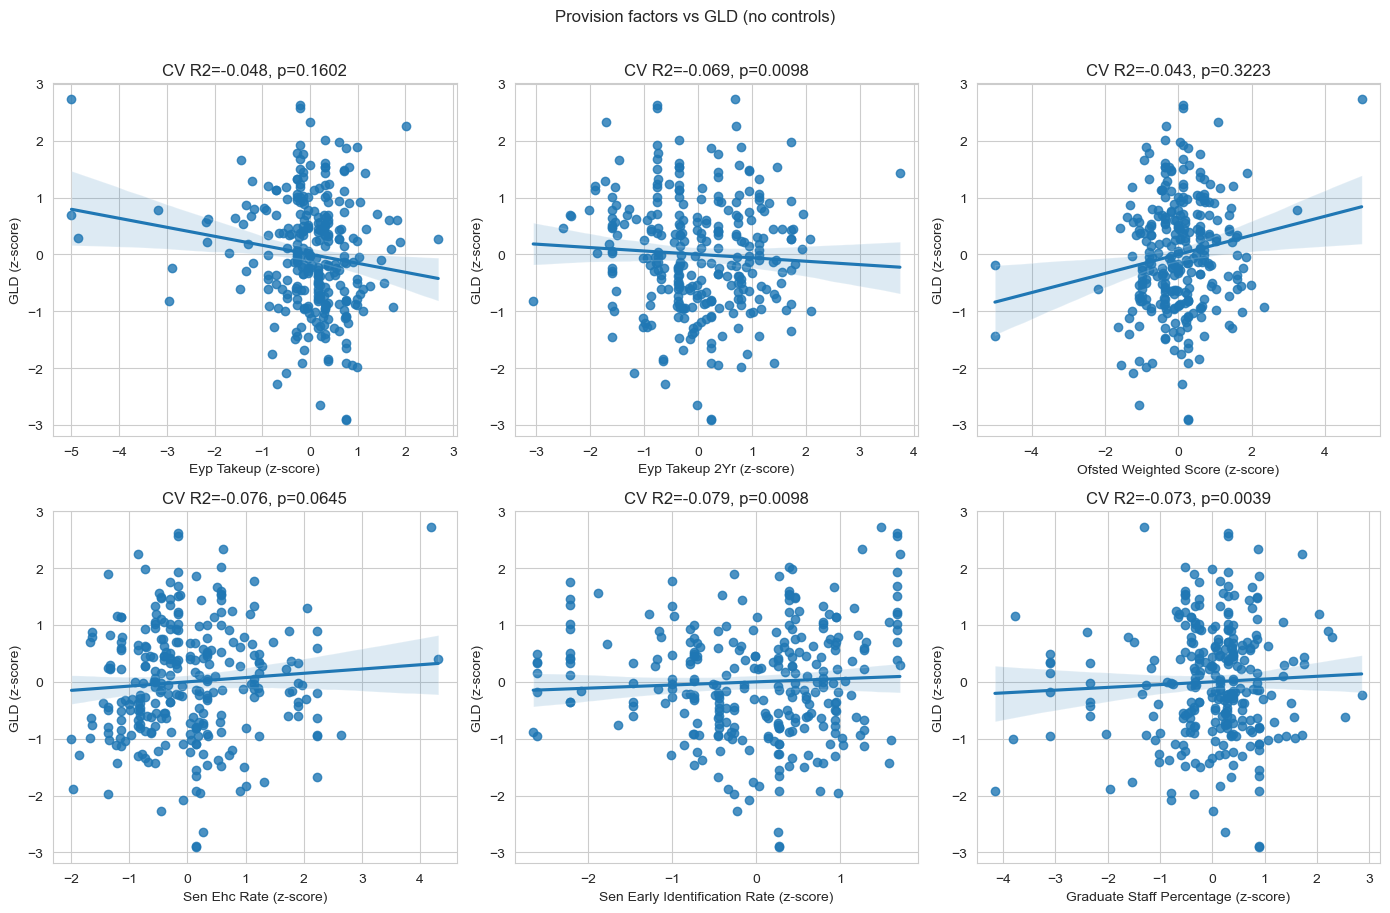

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, col in zip(axes.flatten(), provision_cols):
    r2 = prov_nocontrol_results[col]["cv_r2"]
    p = prov_nocontrol_results[col]["cv_p"]
    label = col.replace("_", " ").title()
    sns.regplot(x=merged[col], y=merged_gld, ax=ax)
    ax.set_xlabel(f"{label} (z-score)")
    ax.set_ylabel("GLD (z-score)")
    ax.set_title(f"CV R2={r2:.3f}, p={p:.4f}")
fig.suptitle("Provision factors vs GLD (no controls)", y=1.01)
plt.tight_layout()

fig.savefig(PROJECT_ROOT / "docs" / "raw_provisions_gld.png")

None of the provision measures show a meaningful relationship with GLD, even before any controls.
Now with wealth regressed out of both GLD and each provision factor...

In [41]:
merged["gld_sub_wealth"] = fit(merged_gld, merged_wealth, weights=merged_weights).resid

prov_sub_wealth = pd.DataFrame(index=merged.index)
for col in provision_cols:
    prov_sub_wealth[col] = fit(merged[col], merged_wealth, weights=merged_weights).resid

prov_wealth_results = {}
for col in provision_cols:
    m = fit(merged["gld_sub_wealth"], prov_sub_wealth[col], weights=merged_weights)
    cv_mean, cv_std, cv_p = cv_r2(prov_sub_wealth[col], merged["gld_sub_wealth"], weights=merged_weights)
    prov_wealth_results[col] = {
        "r2": m.rsquared,
        "coef": m.params.iloc[-1],
        "cv_r2": cv_mean,
        "cv_std": cv_std,
        "cv_p": cv_p,
    }

prov_wealth_summary = pd.DataFrame(prov_wealth_results).T.sort_values("r2", ascending=False)
prov_wealth_summary.style.format({
    "r2": "{:.3f}", "coef": "{:+.3f}",
    "cv_r2": "{:.3f}", "cv_std": "{:.3f}", "cv_p": "{:.1e}",
})

,r2,coef,cv_r2,cv_std,cv_p
eyp_takeup,0.039,+0.213,-0.019,0.112,9.2e-01
sen_early_identification_rate,0.008,-0.076,-0.051,0.052,2.0e-02
graduate_staff_percentage,0.001,-0.031,-0.063,0.061,2.0e-03
sen_ehc_rate,0.001,+0.025,-0.056,0.040,2.0e-03
eyp_takeup_2yr,0.000,+0.009,-0.056,0.045,2.0e-03
ofsted_weighted_score,0.000,+0.008,-0.058,0.044,2.0e-03


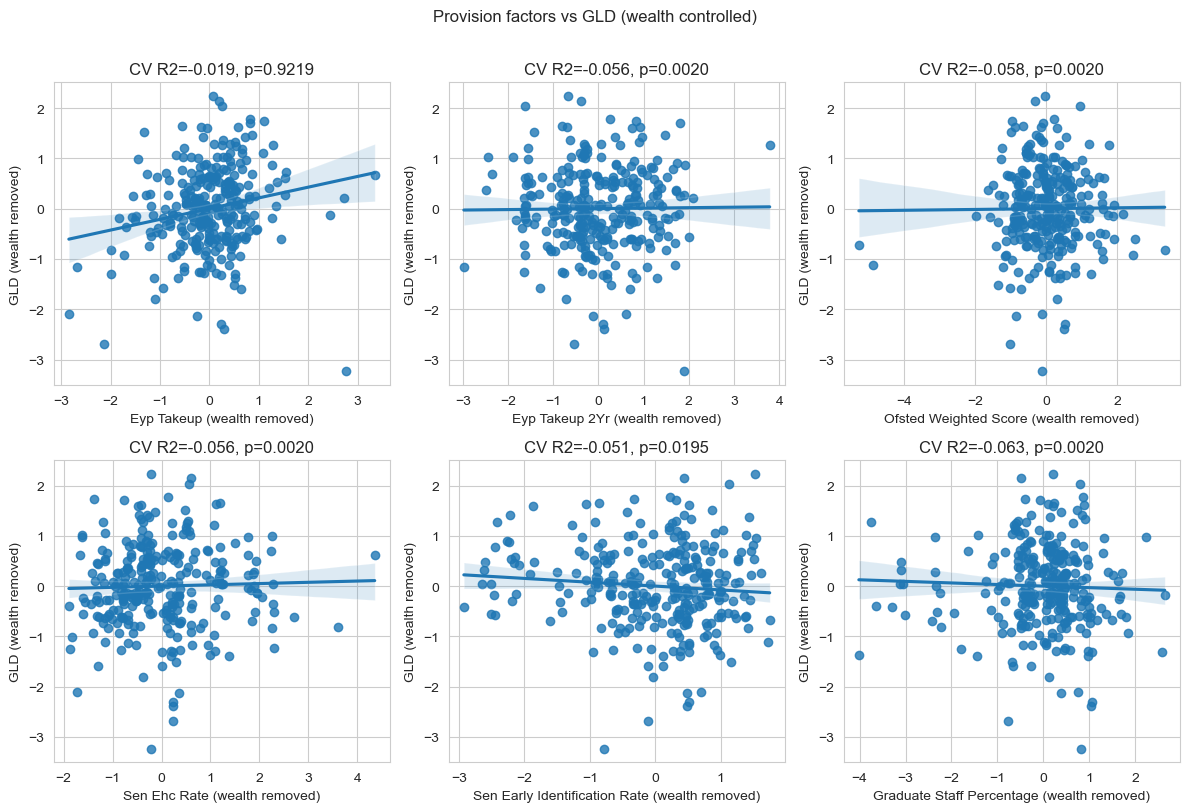

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flatten(), provision_cols):
    r2 = prov_wealth_results[col]["cv_r2"]
    p = prov_wealth_results[col]["cv_p"]
    label = col.replace("_", " ").title()
    sns.regplot(x=prov_sub_wealth[col], y=merged["gld_sub_wealth"], ax=ax)
    ax.set_xlabel(f"{label} (wealth removed)")
    ax.set_ylabel("GLD (wealth removed)")
    ax.set_title(f"CV R2={r2:.3f}, p={p:.4f}")
fig.suptitle("Provision factors vs GLD (wealth controlled)", y=1.01)
plt.tight_layout()

Controlling for wealth doesn't change this - provisions still don't predict GLD.

### Part 3: Do provisions explain GLD variance *beyond* deprivation?

Part 2 showed that my selection of provision factors (childcare take-up, provider quality, SEN support) were not predictive of GLD outcomes. It is therefore unlikely that they would predict GLD after controlling for deprivation. However, for completeness I now test whether provisions predict the GLD variance that deprivation can't explain - i.e., the residuals from a model of GLD predicted by the deprivation component (PC1).

In [43]:
model_pc1 = fit(gld_sub_wealth, df_iod["PC1"], weights=weights)
merged["gld_resid"] = model_pc1.resid.values

prov_resid_results = {}
for col in provision_cols:
    m = fit(merged["gld_resid"], prov_sub_wealth[col], weights=merged_weights)
    cv_mean, cv_std, cv_p = cv_r2(prov_sub_wealth[col], merged["gld_resid"], weights=merged_weights)
    prov_resid_results[col] = {
        "r2": m.rsquared,
        "coef": m.params.iloc[-1],
        "cv_r2": cv_mean,
        "cv_std": cv_std,
        "cv_p": cv_p,
    }

prov_resid_summary = pd.DataFrame(prov_resid_results).T.sort_values("r2", ascending=False)
prov_resid_summary.style.format({
    "r2": "{:.3f}", "coef": "{:+.3f}",
    "cv_r2": "{:.3f}", "cv_std": "{:.3f}", "cv_p": "{:.3f}",
})

,r2,coef,cv_r2,cv_std,cv_p
ofsted_weighted_score,0.001,+0.021,-0.054,0.054,0.006
eyp_takeup,0.001,+0.021,-0.054,0.056,0.004
sen_early_identification_rate,0.000,-0.009,-0.056,0.043,0.002
sen_ehc_rate,0.000,-0.008,-0.058,0.046,0.002
graduate_staff_percentage,0.000,+0.005,-0.054,0.055,0.002
eyp_takeup_2yr,0.000,+0.003,-0.052,0.051,0.002


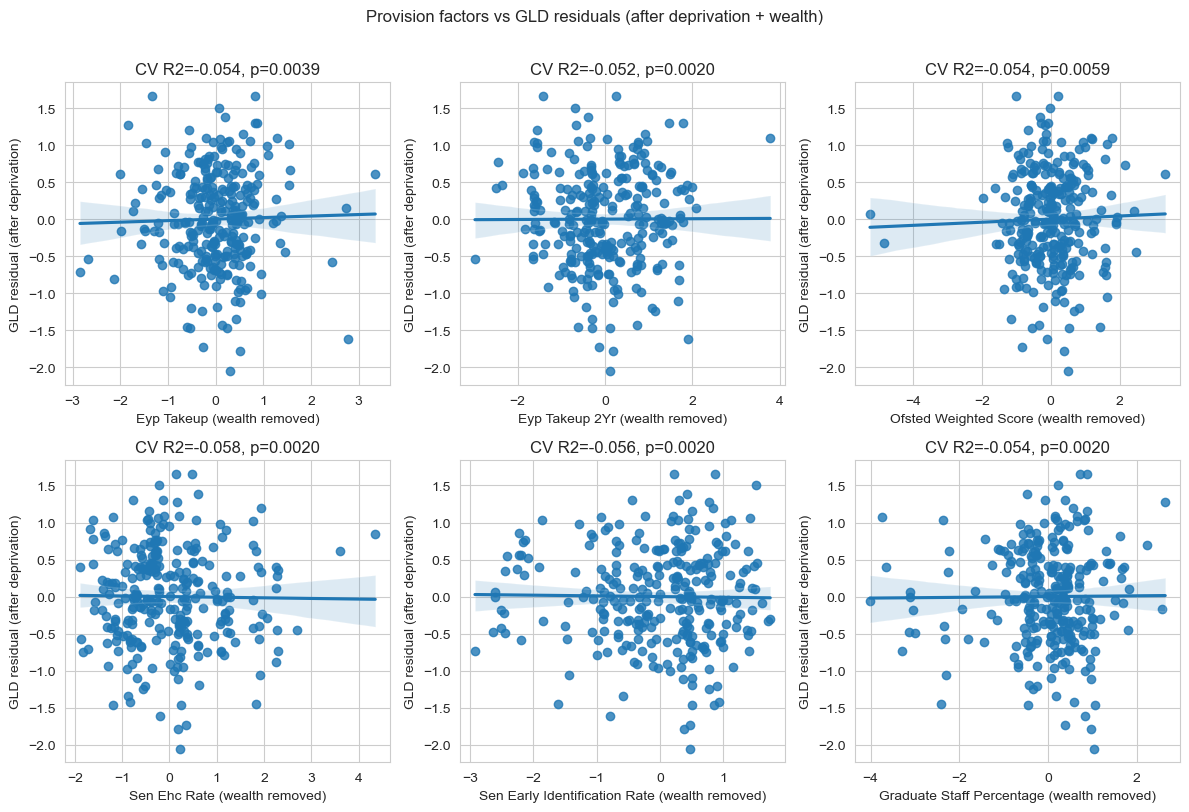

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flatten(), provision_cols):
    r2 = prov_resid_results[col]["cv_r2"]
    p = prov_resid_results[col]["cv_p"]
    label = col.replace("_", " ").title()
    sns.regplot(x=prov_sub_wealth[col], y=merged["gld_resid"], ax=ax)
    ax.set_xlabel(f"{label} (wealth removed)")
    ax.set_ylabel("GLD residual (after deprivation)")
    ax.set_title(f"CV R2={r2:.3f}, p={p:.4f}")
fig.suptitle("Provision factors vs GLD residuals (after deprivation + wealth)", y=1.01)
plt.tight_layout()

As expected from Part 2, provisions don't explain the remaining GLD variance after deprivation either. Whatever is driving the differences between areas that deprivation doesn't capture, it doesn't appear to be picked up by these aggregate provision measures, at least on a local authority district level scale.